<a href="https://colab.research.google.com/github/1816x/Algoritmos-Aprendizaje-Automatico/blob/main/Practica%20Tema%207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nivel 1

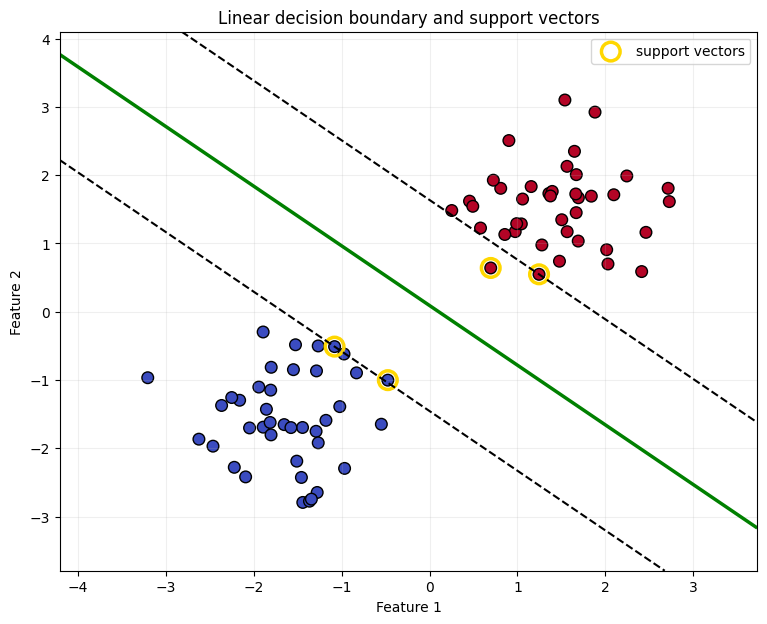

Number of support vectors: 4


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# create the dataset
X_margin, y_margin = make_blobs(
    n_samples=80,
    centers=[(-1.5, -1.5), (1.5, 1.5)],
    cluster_std=0.65,
    random_state=42
)

# create and train the model
svm_vis = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0))
])

svm_vis.fit(X_margin, y_margin)

# create the background grid
x_min, x_max = X_margin[:, 0].min() - 1, X_margin[:, 0].max() + 1
y_min, y_max = X_margin[:, 1].min() - 1, X_margin[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]
decision_values = svm_vis.decision_function(grid).reshape(xx.shape)

# recover support vectors in their original scale
scaler = svm_vis.named_steps["scaler"]
svc = svm_vis.named_steps["svc"]
support_vectors = scaler.inverse_transform(svc.support_vectors_)

# draw the data
plt.figure(figsize=(9, 7))

plt.scatter(
    X_margin[:, 0],
    X_margin[:, 1],
    c=y_margin,
    cmap="coolwarm",
    edgecolor="black",
    s=70
)

# draw the hyperplane and margins
plt.contour(
    xx,
    yy,
    decision_values,
    levels=[-1, 0, 1],
    colors=["black", "green", "black"],
    linestyles=["--", "-", "--"],
    linewidths=[1.5, 2.5, 1.5]
)

# mark support vectors
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=180,
    facecolors="none",
    edgecolors="gold",
    linewidths=2.5,
    label="support vectors"
)

plt.title("Linear decision boundary and support vectors")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Number of support vectors:", len(support_vectors))

nivel 2

In [2]:
import numpy as np

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# create the dataset
X, y = make_blobs(
    n_samples=100,
    centers=[(-2, -2), (2, 2)],
    cluster_std=0.8,
    random_state=7
)

# create and train the model
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear", C=1.0))
])

modelo.fit(X, y)

# extract the trained components
scaler = modelo.named_steps["scaler"]
svc = modelo.named_steps["svc"]

w = svc.coef_[0]
b = svc.intercept_[0]

# define and transform the new point
x_nuevo = np.array([[0.5, 0.5]])
x_escalado = scaler.transform(x_nuevo)

# calculate the decision function manually
f_manual = np.dot(w, x_escalado[0]) + b

# calculate it using scikit-learn
f_modelo = modelo.decision_function(x_nuevo)[0]

print("w:", w)
print("b:", b)
print("Original point:", x_nuevo[0])
print("Scaled point:", x_escalado[0])
print("Manual f(x):", f_manual)
print("Model f(x):", f_modelo)

if f_manual >= 0:
    print("Predicted class: 1")
else:
    print("Predicted class: 0")

print("Model prediction:", modelo.predict(x_nuevo)[0])

w: [0.94022056 0.97783633]
b: -0.14754410795633485
Original point: [0.5 0.5]
Scaled point: [0.2574463  0.23633919]
Manual f(x): 0.32561324853896734
Model f(x): 0.32561324853896745
Predicted class: 1
Model prediction: 1


nivel 3

C=0.01   | support vectors=118 | training accuracy=0.867
C=0.1    | support vectors=73  | training accuracy=0.847
C=1      | support vectors=57  | training accuracy=0.853
C=10     | support vectors=54  | training accuracy=0.847
C=100    | support vectors=53  | training accuracy=0.847


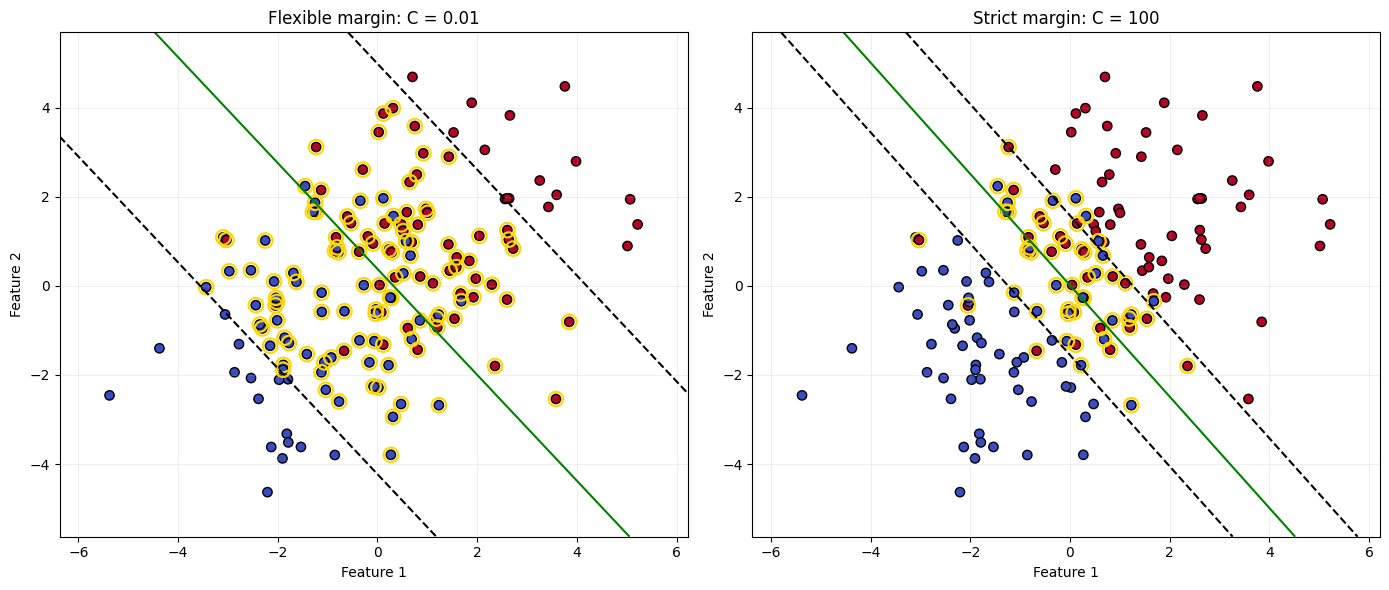

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# create an overlapping dataset
X_ruido, y_ruido = make_blobs(
    n_samples=150,
    centers=[(-1, -1), (1, 1)],
    cluster_std=1.5,
    random_state=3
)

c_values = [0.01, 0.1, 1, 10, 100]
models = {}

# train one model for each c value
for c_value in c_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=c_value))
    ])

    model.fit(X_ruido, y_ruido)
    models[c_value] = model

    number_support_vectors = model.named_steps["svc"].n_support_.sum()
    accuracy = model.score(X_ruido, y_ruido)

    print(
        f"C={c_value:<6} | "
        f"support vectors={number_support_vectors:<3} | "
        f"training accuracy={accuracy:.3f}"
    )

# create a function to draw a model
def plot_boundary(ax, model, title):
    x_min, x_max = X_ruido[:, 0].min() - 1, X_ruido[:, 0].max() + 1
    y_min, y_max = X_ruido[:, 1].min() - 1, X_ruido[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    values = model.decision_function(grid).reshape(xx.shape)

    ax.scatter(
        X_ruido[:, 0],
        X_ruido[:, 1],
        c=y_ruido,
        cmap="coolwarm",
        edgecolor="black",
        s=45
    )

    ax.contour(
        xx,
        yy,
        values,
        levels=[-1, 0, 1],
        colors=["black", "green", "black"],
        linestyles=["--", "-", "--"]
    )

    scaler = model.named_steps["scaler"]
    svc = model.named_steps["svc"]
    support_vectors = scaler.inverse_transform(svc.support_vectors_)

    ax.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        s=110,
        facecolors="none",
        edgecolors="gold",
        linewidths=1.5
    )

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(alpha=0.2)

# compare the extreme values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_boundary(axes[0], models[0.01], "Flexible margin: C = 0.01")
plot_boundary(axes[1], models[100], "Strict margin: C = 100")

plt.tight_layout()
plt.show()

nivel 4

In [4]:
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# create a noisy classification dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,
    flip_y=0.05,
    random_state=11
)

# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=11
)

results = []

# compare a moderate and an extreme c value
for c_value in [1.0, 100000]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=c_value))
    ])

    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    support_vectors = model.named_steps["svc"].n_support_.sum()

    results.append({
        "C": c_value,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "accuracy_gap": train_accuracy - test_accuracy,
        "support_vectors": support_vectors
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

,C,train_accuracy,test_accuracy,accuracy_gap,support_vectors
0,1.0,0.9143,0.9167,-0.0024,42
1,100000.0,0.9143,0.9333,-0.0190,37


final

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# create a synthetic dataset with controlled overlap
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.9,
    flip_y=0.08,
    random_state=25
)

# create training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=25
)

# define logarithmic c values
c_values = np.logspace(-2, 2, 5)

models = {}
results = []

# train and evaluate every model
for c_value in c_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=c_value))
    ])

    model.fit(X_train, y_train)
    models[c_value] = model

    results.append({
        "C": c_value,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test),
        "support_vectors": model.named_steps["svc"].n_support_.sum()
    })

results_df = pd.DataFrame(results)
display(results_df.round(4))

# choose the model with the highest test accuracy
best_index = results_df["test_accuracy"].idxmax()
best_c = results_df.loc[best_index, "C"]
best_model = models[best_c]

print(f"Best C value: {best_c}")
print(f"Best test accuracy: {results_df.loc[best_index, 'test_accuracy']:.4f}")
print(f"Support vectors: {results_df.loc[best_index, 'support_vectors']}")

,C,train_accuracy,test_accuracy,support_vectors
0,0.01,0.8571,0.8000,164
1,0.10,0.9190,0.8778,82
2,1.00,0.9238,0.8778,55
3,10.00,0.9286,0.8778,51
4,100.00,0.9286,0.8778,51


Best C value: 0.1
Best test accuracy: 0.8778
Support vectors: 82


grafica de resultados

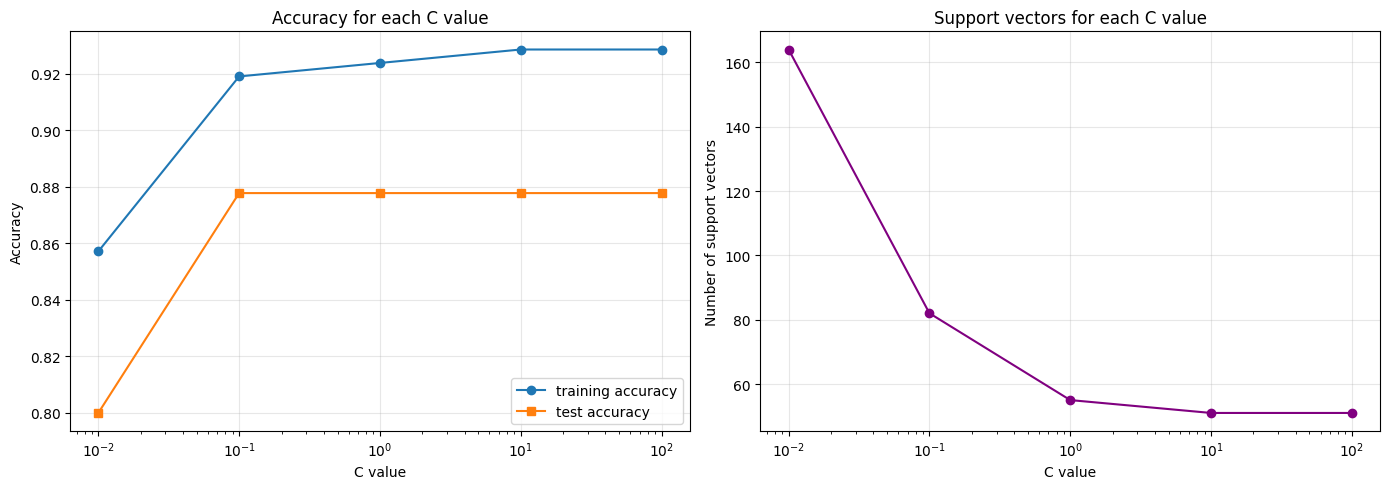

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy graph
axes[0].plot(
    results_df["C"],
    results_df["train_accuracy"],
    marker="o",
    label="training accuracy"
)

axes[0].plot(
    results_df["C"],
    results_df["test_accuracy"],
    marker="s",
    label="test accuracy"
)

axes[0].set_xscale("log")
axes[0].set_title("Accuracy for each C value")
axes[0].set_xlabel("C value")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# support vector graph
axes[1].plot(
    results_df["C"],
    results_df["support_vectors"],
    marker="o",
    color="purple"
)

axes[1].set_xscale("log")
axes[1].set_title("Support vectors for each C value")
axes[1].set_xlabel("C value")
axes[1].set_ylabel("Number of support vectors")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

frontera mejor modelo

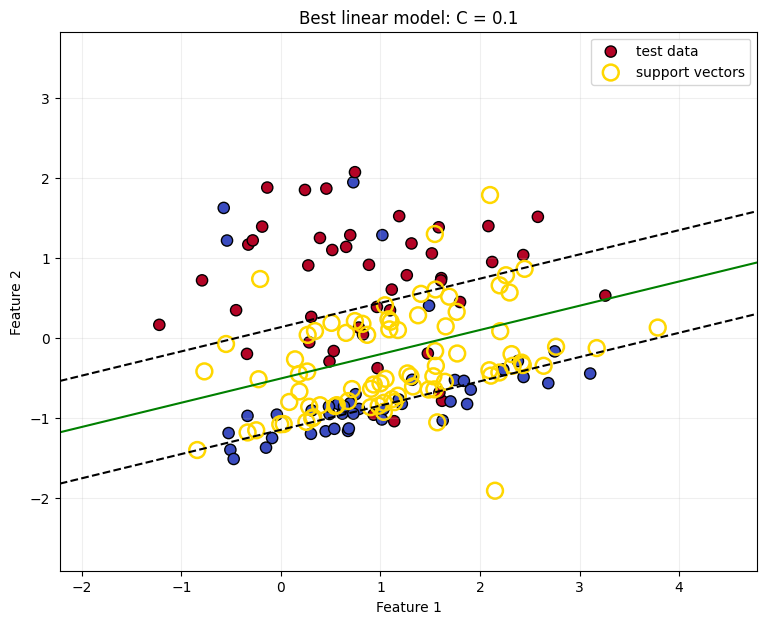

In [7]:
# create the background grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]
decision_values = best_model.decision_function(grid).reshape(xx.shape)

# recover the support vectors
scaler = best_model.named_steps["scaler"]
svc = best_model.named_steps["svc"]
support_vectors = scaler.inverse_transform(svc.support_vectors_)

# draw the best model
plt.figure(figsize=(9, 7))

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="coolwarm",
    edgecolor="black",
    s=65,
    label="test data"
)

plt.contour(
    xx,
    yy,
    decision_values,
    levels=[-1, 0, 1],
    colors=["black", "green", "black"],
    linestyles=["--", "-", "--"]
)

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=130,
    facecolors="none",
    edgecolors="gold",
    linewidths=1.8,
    label="support vectors"
)

plt.title(f"Best linear model: C = {best_c}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()